In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
# Ganti 'folder_kamu/test.zip' dengan lokasi asli di Drive
!unzip -q "/content/drive/MyDrive//train.zip" -d "/content/dataset"
!unzip -q "/content/drive/MyDrive//test.zip" -d "/content/dataset"


Mounted at /content/drive


# 🛡️ Face Anti-Spoofing v3 — Bug Fixes + Improvements

## 🔧 Fix dari analisis log v2:

| # | Bug / Masalah | Fix |
|---|---|---|
| 1 | **EfficientNetV2 unfroze 0 params** (timm pakai struktur berbeda) | Ganti ke `timm` named modules, unfreeze by block name |
| 2 | **Early stopping counter tidak reset antar stage** | Reset patience counter di awal setiap stage baru |
| 3 | **TrAcc = 0.0 saat Mixup/CutMix** | Track accuracy hanya saat plain batch, atau matikan mix di akhir training |
| 4 | **ResNet50 plateau di ~89% F1** | Unfreeze lebih dalam (3 layer) + tambah stage warmup per-stage |
| 5 | **EfficientNetV2 konvergensi lambat** | LR head lebih rendah untuk EffNet, gunakan layer-wise LR decay |

## 1. Install & Import

In [2]:
!pip install timm --quiet

In [4]:
import os, random, warnings, re
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## 2. Konfigurasi

In [5]:
TRAIN_DIR   = Path('dataset/train')   # ← sesuaikan
TEST_DIR    = Path('dataset/test')    # ← sesuaikan
OUTPUT_CSV  = Path('submission_v3.csv')
CKPT_RESNET = Path('best_resnet50_v3.pth')
CKPT_EFFNET = Path('best_efficientnet_v3.pth')

CLASS_NAMES = [
    'realperson', 'fake_printed', 'fake_screen',
    'fake_mask', 'fake_mannequin', 'fake_unknown'
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}

BATCH_SIZE     = 32
VAL_SPLIT      = 0.2
NUM_WORKERS    = 0
WEIGHT_DECAY   = 1e-4

# FIX #4: Unfreeze lebih dalam di stage 3 & 4
# (stage_idx 0-based, unfreeze_n_layers)
RESNET_UNFREEZE_SCHEDULE = {
    0: 0,   # Stage 1: head only
    1: 2,   # Stage 2: unfreeze layer3 + layer4
    2: 3,   # Stage 3: unfreeze layer2 + layer3 + layer4
    3: 4,   # Stage 4: unfreeze layer1 + layer2 + layer3 + layer4
}
EFFNET_UNFREEZE_SCHEDULE = {
    0: 0,   # Stage 1: head only
    1: 3,   # Stage 2: unfreeze last 3 blocks
    2: 5,   # Stage 3: unfreeze last 5 blocks
    3: 7,   # Stage 4: unfreeze last 7 blocks
}

# FIX #2: Patience per-stage (bukan global)
PATIENCE_PER_STAGE = 4

# Progressive stages: (img_size, max_epochs, lr_head, lr_backbone)
PROG_STAGES = [
    (128, 6,  1e-3,  0.0),     # warmup head
    (192, 8,  7e-4,  7e-5),    # partial unfreeze
    (224, 10, 4e-4,  4e-5),    # main training
    (256, 6,  2e-4,  2e-5),    # short refinement only
]

MIXUP_ALPHA  = 0.4
CUTMIX_ALPHA = 1.0
# FIX #3: Kurangi probabilitas mix agar tracking acc lebih readable
# dan di stage terakhir dimatikan biar model converge
MIX_PROB_PER_STAGE = [0.6, 0.4, 0.3, 0.1]   # turun di stage akhir

print('Config loaded.')
print(f'Progressive stages: {[(s,e) for s,e,*_ in PROG_STAGES]}')

Config loaded.
Progressive stages: [(128, 6), (192, 8), (224, 10), (256, 6)]


## 3. Transforms & Augmentasi

In [6]:
def get_train_transform(img_size):
    return T.Compose([
        T.Resize((int(img_size * 1.15), int(img_size * 1.15))),
        T.RandomCrop(img_size),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.1),
        T.RandomRotation(degrees=20),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
        T.RandomGrayscale(p=0.15),
        T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),
        T.RandomPerspective(distortion_scale=0.3, p=0.3),
        T.RandomAffine(degrees=0, translate=(0.05,0.05), scale=(0.85,1.15), shear=10),
        T.RandomApply([T.RandomSolarize(threshold=128)], p=0.1),
        T.RandomAutocontrast(p=0.2),
        T.RandomEqualize(p=0.1),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        T.RandomErasing(p=0.35, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    ])

def get_val_transform(img_size):
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

def get_tta_transforms(img_size=224):
    norm = T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    return [
        T.Compose([T.Resize((img_size,img_size)), T.ToTensor(), norm]),
        T.Compose([T.Resize((img_size,img_size)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), norm]),
        T.Compose([T.Resize((int(img_size*1.14),int(img_size*1.14))), T.CenterCrop(img_size), T.ToTensor(), norm]),
        T.Compose([T.Resize((img_size,img_size)), T.RandomRotation((90,90)), T.ToTensor(), norm]),
        T.Compose([T.Resize((img_size,img_size)), T.RandomRotation((-90,-90)), T.ToTensor(), norm]),
    ]

print('Transforms ready (5-pass TTA)')

Transforms ready (5-pass TTA)


## 4. Mixup & CutMix

In [7]:
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    W, H = x.size(3), x.size(2)
    cut_w, cut_h = int(W*np.sqrt(1-lam)), int(H*np.sqrt(1-lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(cx-cut_w//2,0), max(cy-cut_h//2,0)
    x2,y2 = min(cx+cut_w//2,W), min(cy+cut_h//2,H)
    mixed = x.clone()
    mixed[:,:,y1:y2,x1:x2] = x[idx,:,y1:y2,x1:x2]
    lam = 1 - (y2-y1)*(x2-x1)/(W*H)
    return mixed, y, y[idx], lam

def mix_criterion(criterion, pred, y_a, y_b, lam):
    return lam*criterion(pred,y_a) + (1-lam)*criterion(pred,y_b)

## 5. Dataset

In [8]:
class FaceDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img) if self.transform else img, label

class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.transform = transform
        self.paths = sorted([p for p in Path(test_dir).iterdir()
                             if p.suffix.lower() in ['.jpg','.jpeg','.png']])
        self.ids   = [p.stem for p in self.paths]
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img, self.ids[idx]

def load_samples(train_dir, class_names):
    samples = []
    for cls in class_names:
        d = Path(train_dir) / cls
        if not d.exists(): print(f'⚠ skip {d}'); continue
        for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']:
            for p in d.glob(ext):
                samples.append((str(p), CLASS2IDX[cls]))
    return samples

all_samples  = load_samples(TRAIN_DIR, CLASS_NAMES)
paths_all    = [s[0] for s in all_samples]
labels_all   = [s[1] for s in all_samples]

paths_tr, paths_va, labels_tr, labels_va = train_test_split(
    paths_all, labels_all, test_size=VAL_SPLIT,
    random_state=SEED, stratify=labels_all
)
train_samples = list(zip(paths_tr, labels_tr))
val_samples   = list(zip(paths_va, labels_va))

label_counts = Counter(labels_all)
print(f'Total: {len(all_samples)} | Train: {len(train_samples)} | Val: {len(val_samples)}')
print('\nDistribusi per kelas:')
for cls, idx in CLASS2IDX.items():
    print(f'  {cls:20s}: {label_counts.get(idx,0):4d}')

# WeightedRandomSampler
tr_cnt     = Counter(labels_tr)
sample_wts = [1.0/tr_cnt[l] for l in labels_tr]
sampler    = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

# Class weights untuk loss
total = sum(label_counts.values())
cls_weights = torch.tensor(
    [total / (NUM_CLASSES * label_counts.get(i,1)) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(DEVICE)
print(f'\nClass weights: {cls_weights.cpu().numpy().round(3)}')

Total: 1637 | Train: 1309 | Val: 328

Distribusi per kelas:
  realperson          :  450
  fake_printed        :  139
  fake_screen         :  201
  fake_mask           :  268
  fake_mannequin      :  227
  fake_unknown        :  352

Class weights: [0.606 1.963 1.357 1.018 1.202 0.775]


## 6. Focal Loss

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt   = torch.exp(-ce)
        loss = (1 - pt)**self.gamma * ce
        return loss.mean()

criterion = FocalLoss(alpha=cls_weights, gamma=2.0)
print('Focal Loss ready')

Focal Loss ready


## 7. GeM Pooling

In [10]:
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1)*p)
        self.eps = eps
    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1
        ).pow(1.0/self.p)

class SpoofingHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.BatchNorm1d(512),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.GELU(), nn.Dropout(dropout/2),
            nn.Linear(256, num_classes),
        )
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x): return self.net(x)

## 8. Model — ResNet50 (sama seperti v2, sudah benar)

In [11]:
class ResNet50Spoof(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        bb = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(bb.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.gem = GeM(p=3)
        self.head = SpoofingHead(bb.fc.in_features * 3, num_classes)
        self._freeze_all_backbone()

    def _freeze_all_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def set_unfreeze_n(self, n):
        """
        Unfreeze N layer terakhir backbone.
        ResNet50 layers idx: 0=conv1,1=bn1,2=relu,3=maxpool,
                             4=layer1,5=layer2,6=layer3,7=layer4
        """
        self._freeze_all_backbone()
        if n == 0: return
        layers = list(self.backbone.children())
        for layer in layers[-n:]:
            for p in layer.parameters(): p.requires_grad = True
        n_tr = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        print(f'  [ResNet50] Unfreeze {n} layers → {n_tr:,} backbone params trainable')

    def forward(self, x):
        f = self.backbone(x)
        return self.head(torch.cat([self.gap(f), self.gmp(f), self.gem(f)], dim=1))

## 9. Model — EfficientNetV2-S (FIX #1: unfreeze benar untuk timm)

In [12]:
class EfficientNetV2Spoof(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        # FIX: features_only=False, num_classes=0 → output adalah feature map sebelum head
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=True,
            num_classes=0,
            global_pool='',        # kita handle pooling sendiri
        )
        in_feat   = self.backbone.num_features   # 1280
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.gmp  = nn.AdaptiveMaxPool2d(1)
        self.gem  = GeM(p=3)
        self.head = SpoofingHead(in_feat * 3, num_classes)
        self._freeze_all_backbone()

    def _freeze_all_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def get_backbone_blocks(self):
        """
        FIX #1: Untuk timm EfficientNetV2, blok-blok ada di self.backbone.blocks
        Gunakan named children untuk cek struktur yang benar.
        """
        # Cek apakah model punya atribut 'blocks' (EfficientNet timm punya)
        if hasattr(self.backbone, 'blocks'):
            return list(self.backbone.blocks.children())
        # Fallback: pakai semua named children
        return list(self.backbone.children())

    def set_unfreeze_n(self, n):
        """
        Unfreeze N block terakhir dari EfficientNetV2.
        EfficientNetV2-S punya ~6 stage blocks di self.backbone.blocks.
        """
        self._freeze_all_backbone()
        if n == 0: return

        blocks = self.get_backbone_blocks()
        n_actual = min(n, len(blocks))
        for block in blocks[-n_actual:]:
            for p in block.parameters(): p.requires_grad = True

        # Selalu unfreeze BatchNorm global (conv_head, bn2, dll)
        for name, module in self.backbone.named_modules():
            if 'conv_head' in name or 'bn2' in name or 'norm_head' in name:
                for p in module.parameters(): p.requires_grad = True

        n_tr = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        print(f'  [EfficientNetV2] Unfreeze {n_actual}/{len(blocks)} blocks → {n_tr:,} backbone params trainable')

    def forward(self, x):
        f = self.backbone(x)
        return self.head(torch.cat([self.gap(f), self.gmp(f), self.gem(f)], dim=1))


# ── Verifikasi struktur EfficientNetV2 ────────────────────────────────────────
print('Verifikasi struktur EfficientNetV2-S:')
_tmp = EfficientNetV2Spoof(NUM_CLASSES).to(DEVICE)
blocks = _tmp.get_backbone_blocks()
print(f'  Jumlah blocks: {len(blocks)}')
print(f'  Block types  : {[type(b).__name__ for b in blocks]}')

# Test unfreeze
print('\nTest unfreeze 3 blocks:')
_tmp.set_unfreeze_n(3)
n_tr = sum(p.numel() for p in _tmp.backbone.parameters() if p.requires_grad)
assert n_tr > 0, '❌ MASIH 0 — perlu debugging lebih lanjut'
print(f'  ✅ {n_tr:,} params berhasil di-unfreeze')
del _tmp

Verifikasi struktur EfficientNetV2-S:


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

  Jumlah blocks: 6
  Block types  : ['Sequential', 'Sequential', 'Sequential', 'Sequential', 'Sequential', 'Sequential']

Test unfreeze 3 blocks:
  [EfficientNetV2] Unfreeze 3/6 blocks → 19,274,488 backbone params trainable
  ✅ 19,274,488 params berhasil di-unfreeze


## 10. SAM Optimizer

In [13]:
class SAM(optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for g in self.param_groups:
            scale = g['rho'] / (grad_norm + 1e-12)
            for p in g['params']:
                if p.grad is None: continue
                e_w = (torch.pow(p,2) if g['adaptive'] else 1.0) * p.grad * scale
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for g in self.param_groups:
            for p in g['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        dev = self.param_groups[0]['params'][0].device
        norms = [
            ((torch.abs(p) if g['adaptive'] else 1.0)*p.grad).norm(2).to(dev)
            for g in self.param_groups for p in g['params'] if p.grad is not None
        ]
        return torch.norm(torch.stack(norms), 2)

    def load_state_dict(self, sd):
        super().load_state_dict(sd)
        self.base_optimizer.param_groups = self.param_groups

print('SAM ready')

SAM ready


## 11. Layer-wise LR Decay untuk EfficientNetV2 (FIX #5)

In [14]:
def get_layerwise_param_groups_effnet(model, lr_head, lr_backbone, decay=0.8):
    """
    FIX #5: Layer-wise LR decay untuk EfficientNetV2.
    Block lebih dalam (early) mendapat LR lebih kecil.
    head_lr > last_block_lr > ... > first_block_lr
    """
    param_groups = []

    # Head + pooling params
    head_params = list(model.head.parameters()) + list(model.gem.parameters())
    param_groups.append({'params': head_params, 'lr': lr_head, 'name': 'head'})

    if lr_backbone == 0.0:
        return param_groups

    blocks = model.get_backbone_blocks()
    # Hanya include blocks yang trainable
    trainable_blocks = [
        (i, b) for i, b in enumerate(blocks)
        if any(p.requires_grad for p in b.parameters())
    ]

    for rank, (i, block) in enumerate(reversed(trainable_blocks)):
        block_lr = lr_backbone * (decay ** rank)
        block_params = [p for p in block.parameters() if p.requires_grad]
        if block_params:
            param_groups.append({
                'params': block_params,
                'lr': block_lr,
                'name': f'block_{i}'
            })

    # Unfreeze conv_head/norm_head
    extra = []
    for name, module in model.backbone.named_modules():
        if any(k in name for k in ['conv_head','bn2','norm_head']):
            extra += [p for p in module.parameters() if p.requires_grad]
    if extra:
        param_groups.append({'params': extra, 'lr': lr_backbone, 'name': 'neck'})

    lrs = [g['lr'] for g in param_groups]
    print(f'  Param groups: {len(param_groups)} | LRs: {[f"{l:.1e}" for l in lrs]}')
    return param_groups


def get_param_groups_resnet(model, lr_head, lr_backbone):
    groups = [{'params': list(model.head.parameters()) + list(model.gem.parameters()),
               'lr': lr_head, 'name': 'head'}]
    bb_params = [p for p in model.backbone.parameters() if p.requires_grad]
    if bb_params and lr_backbone > 0:
        groups.append({'params': bb_params, 'lr': lr_backbone, 'name': 'backbone'})
    return groups


def unique_param_groups(param_groups):
    seen = set()
    clean_groups = []

    for g in param_groups:
        unique_params = []
        for p in g['params']:
            pid = id(p)
            if pid not in seen:
                seen.add(pid)
                unique_params.append(p)

        if unique_params:
            new_g = {k: v for k, v in g.items() if k != 'params'}
            new_g['params'] = unique_params
            clean_groups.append(new_g)

    return clean_groups

print('Layer-wise LR decay ready')

Layer-wise LR decay ready


## 12. Training Function (semua fix terintegrasi)

In [15]:
def train_model(model, model_name, ckpt_path, unfreeze_schedule, get_param_fn,
                prog_stages=PROG_STAGES, use_sam=True):
    """
    Training dengan semua fix:
    - FIX #2: patience reset per-stage
    - FIX #3: mix_prob turun di stage akhir
    - FIX #4/#1: unfreeze_schedule per stage
    - FIX #5: layer-wise LR (via get_param_fn)
    """
    history = {'stage':[], 'epoch':[], 'tr_loss':[], 'va_loss':[], 'va_acc':[], 'va_f1':[]}
    best_f1 = 0.0
    global_epoch = 0

    for si, (img_size, stage_epochs, lr_head, lr_bb) in enumerate(prog_stages):
        mix_prob = MIX_PROB_PER_STAGE[si]
        n_unfreeze = unfreeze_schedule.get(si, 0)

        print(f'\n{"="*68}')
        print(f'  [{model_name}] Stage {si+1}/{len(prog_stages)} | '
              f'Size:{img_size}px | Ep:{stage_epochs} | '
              f'LR_head:{lr_head:.0e} | LR_bb:{lr_bb:.0e} | MixProb:{mix_prob}')
        print(f'{"="*68}')

        # ── Unfreeze sesuai jadwal ────────────────────────────────────────────
        model.set_unfreeze_n(n_unfreeze)

        # ── DataLoaders ───────────────────────────────────────────────────────
        tr_ds  = FaceDataset(train_samples, transform=get_train_transform(img_size))
        va_ds  = FaceDataset(val_samples,   transform=get_val_transform(img_size))
        tr_ldr = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
        va_ldr = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

        # ── Optimizer & Scheduler ─────────────────────────────────────────────
        param_groups = get_param_fn(model, lr_head, lr_bb)
        param_groups = unique_param_groups(param_groups)

        if use_sam:
            optimizer = SAM(param_groups, base_optimizer=optim.AdamW,
                            rho=0.05, lr=lr_head, weight_decay=WEIGHT_DECAY)
            base_opt  = optimizer.base_optimizer
        else:
            optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
            base_opt  = optimizer

        max_lrs = [g['lr'] for g in param_groups]
        scheduler = optim.lr_scheduler.OneCycleLR(
            base_opt, max_lr=max_lrs,
            steps_per_epoch=len(tr_ldr),
            epochs=stage_epochs, pct_start=0.3,
            div_factor=25, final_div_factor=1e4,
        )

        # FIX #2: Reset patience setiap stage baru
        stage_best_f1   = 0.0
        patience_count  = 0

        for ep in range(1, stage_epochs+1):
            global_epoch += 1

            # ── TRAIN ─────────────────────────────────────────────────────────
            model.train()
            tr_loss = 0.0
            # FIX #3: track acc hanya untuk plain batch
            plain_correct = plain_total = 0
            mixed_correct = mixed_total = 0

            for imgs, labels in tqdm(tr_ldr, leave=False, desc=f'Stage{si+1} E{ep}'):
                imgs   = imgs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                r = random.random()
                if r < mix_prob * 0.5:
                    imgs, ya, yb, lam = cutmix_data(imgs, labels)
                    use_mix = True
                elif r < mix_prob:
                    imgs, ya, yb, lam = mixup_data(imgs, labels)
                    use_mix = True
                else:
                    use_mix = False

                def compute_loss(logits):
                    if use_mix:
                        return mix_criterion(criterion, logits, ya, yb, lam)
                    return criterion(logits, labels)

                if use_sam:
                    logits = model(imgs)
                    compute_loss(logits).backward()
                    optimizer.first_step(zero_grad=True)
                    logits2 = model(imgs)
                    loss2 = compute_loss(logits2)
                    loss2.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.second_step(zero_grad=True)
                    tr_loss += loss2.item() * imgs.size(0)
                else:
                    optimizer.zero_grad()
                    logits = model(imgs)
                    loss   = compute_loss(logits)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    tr_loss += loss.item() * imgs.size(0)

                scheduler.step()

                # FIX #3: Tracking acc
                preds = (logits2 if use_sam else logits).argmax(1).detach()
                if not use_mix:
                    plain_correct += (preds == labels).sum().item()
                    plain_total   += labels.size(0)
                else:
                    # Soft accuracy: lam*acc_a + (1-lam)*acc_b
                    mixed_correct += (lam*(preds==ya).float() + (1-lam)*(preds==yb).float()).sum().item()
                    mixed_total   += labels.size(0)

            tr_loss /= len(tr_ds)
            # Gabungkan plain + mixed accuracy
            total_cor = plain_correct + mixed_correct
            total_tot = plain_total   + mixed_total
            tr_acc    = total_cor / max(total_tot, 1)

            # ── VALIDATION ────────────────────────────────────────────────────
            model.eval()
            va_loss = 0.0
            all_preds, all_labels = [], []

            with torch.no_grad():
                for imgs, labels in tqdm(va_ldr, leave=False, desc='Val'):
                    imgs   = imgs.to(DEVICE)
                    labels = labels.to(DEVICE)
                    logits = model(imgs)
                    va_loss += criterion(logits, labels).item() * imgs.size(0)
                    all_preds.extend(logits.argmax(1).cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            va_loss /= len(va_ds)
            va_acc   = accuracy_score(all_labels, all_preds)
            va_f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)

            history['stage'].append(si+1)
            history['epoch'].append(global_epoch)
            history['tr_loss'].append(tr_loss)
            history['va_loss'].append(va_loss)
            history['va_acc'].append(va_acc)
            history['val_f1' if 'val_f1' in history else 'va_f1'].append(va_f1)

            cur_lr = scheduler.get_last_lr()[0]

            # ── Checkpoint (global best) ───────────────────────────────────────
            is_global_best = va_f1 > best_f1
            if is_global_best:
                best_f1 = va_f1
                torch.save({
                    'epoch': global_epoch, 'stage': si+1,
                    'model_state_dict': model.state_dict(),
                    'best_val_f1': best_f1, 'class_names': CLASS_NAMES,
                }, ckpt_path)

            # FIX #2: Stage-level early stopping
            if va_f1 > stage_best_f1:
                stage_best_f1 = va_f1
                patience_count = 0
                marker = f'✅ BEST (global={best_f1:.4f})' if is_global_best else f'✅ stage best'
            else:
                patience_count += 1
                marker = f'⏳ {patience_count}/{PATIENCE_PER_STAGE}'

            print(f'  E{ep:3d} | TrL={tr_loss:.4f} TrAcc={tr_acc:.4f} '
                  f'| VaL={va_loss:.4f} VaAcc={va_acc:.4f} VaF1={va_f1:.4f} '
                  f'| LR={cur_lr:.2e} | {marker}')

            if patience_count >= PATIENCE_PER_STAGE:
                print(f'  ⛔ Stage early stop (stage_best={stage_best_f1:.4f})')
                break

    print(f'\n🏆 [{model_name}] Best Global Val F1-Macro: {best_f1:.4f}')
    # fix key name
    if 'va_f1' not in history: history['va_f1'] = history.pop('val_f1', [])
    return history

print('Training function ready')

Training function ready


## 13. Train ResNet50

In [17]:
print('='*68)
print('  TRAINING MODEL 1: ResNet50 v3')
print('='*68)

model_resnet = ResNet50Spoof(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in model_resnet.parameters())
print(f'Total params: {total:,}')

hist_resnet = train_model(
    model_resnet,
    model_name  = 'ResNet50',
    ckpt_path   = CKPT_RESNET,
    unfreeze_schedule = RESNET_UNFREEZE_SCHEDULE,
    get_param_fn      = get_param_groups_resnet,
    use_sam     = True,
)

  TRAINING MODEL 1: ResNet50 v3
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


Total params: 26,788,679

  [ResNet50] Stage 1/4 | Size:128px | Ep:6 | LR_head:1e-03 | LR_bb:0e+00 | MixProb:0.6


Stage1 E1:   0%|          | 0/41 [00:00<?, ?it/s]

Val:   0%|          | 0/11 [00:00<?, ?it/s]

...

Val:   0%|          | 0/11 [00:00<?, ?it/s]

  E  5 | TrL=0.2422 TrAcc=0.8449 | VaL=0.1057 VaAcc=0.8963 VaF1=0.8970 | LR=2.55e-05 | ⏳ 1/4


Stage4 E6:   0%|          | 0/41 [00:00<?, ?it/s]

Val:   0%|          | 0/11 [00:00<?, ?it/s]

  E  6 | TrL=0.2162 TrAcc=0.8604 | VaL=0.1118 VaAcc=0.9024 VaF1=0.9037 | LR=1.74e-08 | ⏳ 2/4

🏆 [ResNet50] Best Global Val F1-Macro: 0.9106


## 14. Train EfficientNetV2-S

In [16]:
print('='*68)
print('  TRAINING MODEL 2: EfficientNetV2-S v3 (FIXED)')
print('='*68)

model_effnet = EfficientNetV2Spoof(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in model_effnet.parameters())
print(f'Total params: {total:,}')

hist_effnet = train_model(
    model_effnet,
    model_name  = 'EfficientNetV2-S',
    ckpt_path   = CKPT_EFFNET,
    unfreeze_schedule = EFFNET_UNFREEZE_SCHEDULE,
    get_param_fn      = get_layerwise_param_groups_effnet,
    use_sam     = True,
)

  TRAINING MODEL 2: EfficientNetV2-S v3 (FIXED)
Total params: 22,278,487

  [EfficientNetV2-S] Stage 1/4 | Size:128px | Ep:6 | LR_head:1e-03 | LR_bb:0e+00 | MixProb:0.6


Stage1 E1:   0%|          | 0/41 [00:00<?, ?it/s]

Val:   0%|          | 0/11 [00:00<?, ?it/s]

  E  1 | TrL=2.0517 TrAcc=0.1827 | VaL=0.8872 VaAcc=0.3902 VaF1=0.4075 | LR=6.15e-04 | ✅ BEST (global=0.4075)


Stage1 E2:   0%|          | 0/41 [00:00<?, ?it/s]

...

Val:   0%|          | 0/11 [00:00<?, ?it/s]

  E  4 | TrL=0.3155 TrAcc=0.7964 | VaL=0.1364 VaAcc=0.8963 VaF1=0.8965 | LR=9.07e-05 | ⏳ 3/4


Stage4 E5:   0%|          | 0/41 [00:00<?, ?it/s]

Val:   0%|          | 0/11 [00:00<?, ?it/s]

  E  5 | TrL=0.3703 TrAcc=0.8002 | VaL=0.1427 VaAcc=0.8963 VaF1=0.8977 | LR=2.55e-05 | ⏳ 4/4
  ⛔ Stage early stop (stage_best=0.9055)

🏆 [EfficientNetV2-S] Best Global Val F1-Macro: 0.9059


## 15. Plot Training History

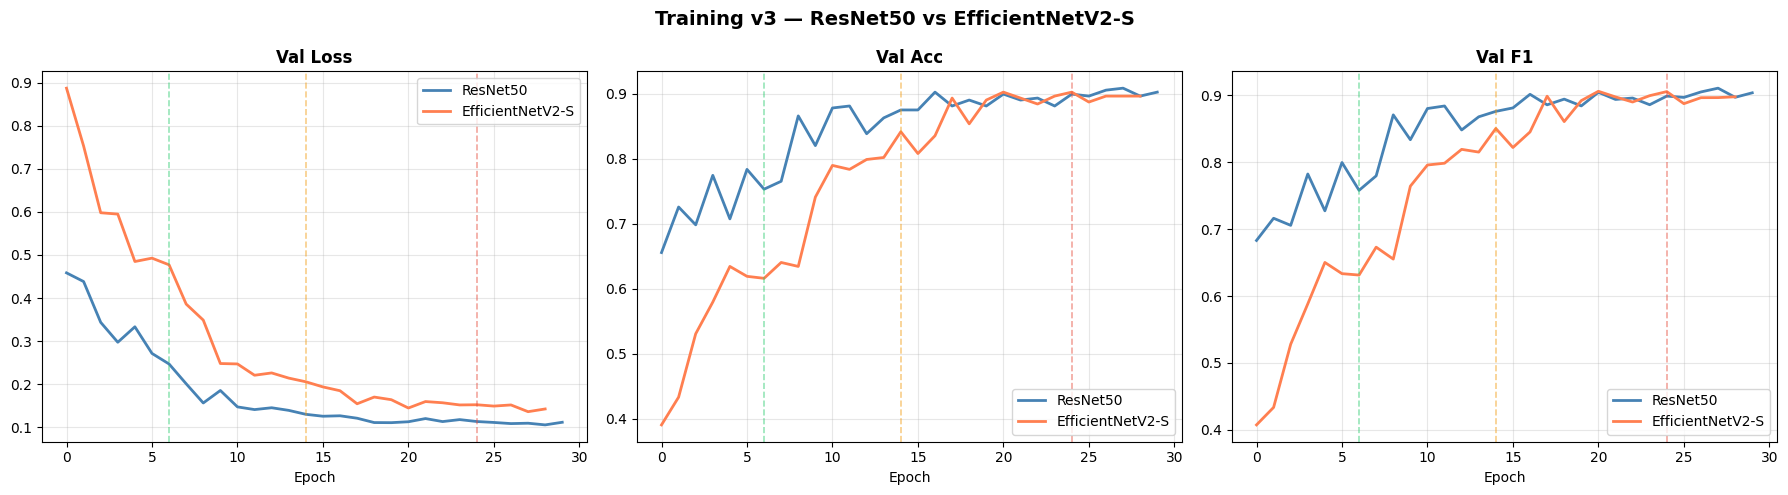

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training v3 — ResNet50 vs EfficientNetV2-S', fontsize=14, fontweight='bold')

metrics = [('Val Loss','va_loss'), ('Val Acc','va_acc'), ('Val F1','va_f1')]
for ax, (title, key) in zip(axes, metrics):
    ax.plot(hist_resnet[key], label='ResNet50',        color='steelblue', lw=2)
    ax.plot(hist_effnet[key], label='EfficientNetV2-S', color='coral',     lw=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

    # Stage boundaries
    boundaries = np.cumsum([e for _,e,*_ in PROG_STAGES])
    for b, c in zip(boundaries[:-1], ['#2ecc71','#f39c12','#e74c3c']):
        ax.axvline(x=b, color=c, ls='--', alpha=0.5, lw=1.2)

plt.tight_layout()
plt.savefig('training_history_v3.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Evaluasi & Ensemble

In [19]:
# Load best weights
ckpt_r = torch.load(CKPT_RESNET, map_location=DEVICE)
model_resnet.load_state_dict(ckpt_r['model_state_dict'])
print(f'ResNet50       : epoch={ckpt_r["epoch"]} stage={ckpt_r["stage"]} F1={ckpt_r["best_val_f1"]:.4f}')

ckpt_e = torch.load(CKPT_EFFNET, map_location=DEVICE)
model_effnet.load_state_dict(ckpt_e['model_state_dict'])
print(f'EfficientNetV2 : epoch={ckpt_e["epoch"]} stage={ckpt_e["stage"]} F1={ckpt_e["best_val_f1"]:.4f}')


def evaluate(model, loader):
    model.eval()
    all_p, all_l, probs_list = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            probs = torch.softmax(model(imgs.to(DEVICE)), 1)
            probs_list.append(probs.cpu().numpy())
            all_p.extend(probs.argmax(1).cpu().numpy())
            all_l.extend(labels.numpy())
    probs_arr = np.concatenate(probs_list)
    f1  = f1_score(all_l, all_p, average='macro', zero_division=0)
    acc = accuracy_score(all_l, all_p)
    return all_l, all_p, probs_arr, f1, acc


val_ds_224  = FaceDataset(val_samples, transform=get_val_transform(224))
val_ldr_224 = DataLoader(val_ds_224, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

gt, preds_r, probs_r, f1_r, acc_r = evaluate(model_resnet, val_ldr_224)
gt, preds_e, probs_e, f1_e, acc_e = evaluate(model_effnet,  val_ldr_224)

# Weighted ensemble
w_r, w_e   = f1_r, f1_e
probs_ens  = (w_r*probs_r + w_e*probs_e) / (w_r + w_e)
preds_ens  = probs_ens.argmax(1)
f1_ens     = f1_score(gt, preds_ens, average='macro', zero_division=0)
acc_ens    = accuracy_score(gt, preds_ens)

print('\n' + '='*58)
print(f'  ResNet50         : Acc={acc_r:.4f}  F1={f1_r:.4f}')
print(f'  EfficientNetV2-S : Acc={acc_e:.4f}  F1={f1_e:.4f}')
print(f'  ── Ensemble ────  : Acc={acc_ens:.4f}  F1={f1_ens:.4f} ⭐')
print('='*58)

ResNet50       : epoch=28 stage=4 F1=0.9106
EfficientNetV2 : epoch=21 stage=3 F1=0.9059


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]


  ResNet50         : Acc=0.9116  F1=0.9111
  EfficientNetV2-S : Acc=0.9024  F1=0.9059
  ── Ensemble ────  : Acc=0.9177  F1=0.9186 ⭐



📋 Ensemble Classification Report
                precision    recall  f1-score   support

    realperson     0.9518    0.8778    0.9133        90
  fake_printed     0.9286    0.9286    0.9286        28
   fake_screen     0.9512    0.9750    0.9630        40
     fake_mask     0.8500    0.9444    0.8947        54
fake_mannequin     0.8200    0.9111    0.8632        45
  fake_unknown     0.9848    0.9155    0.9489        71

      accuracy                         0.9177       328
     macro avg     0.9144    0.9254    0.9186       328
  weighted avg     0.9221    0.9177    0.9184       328



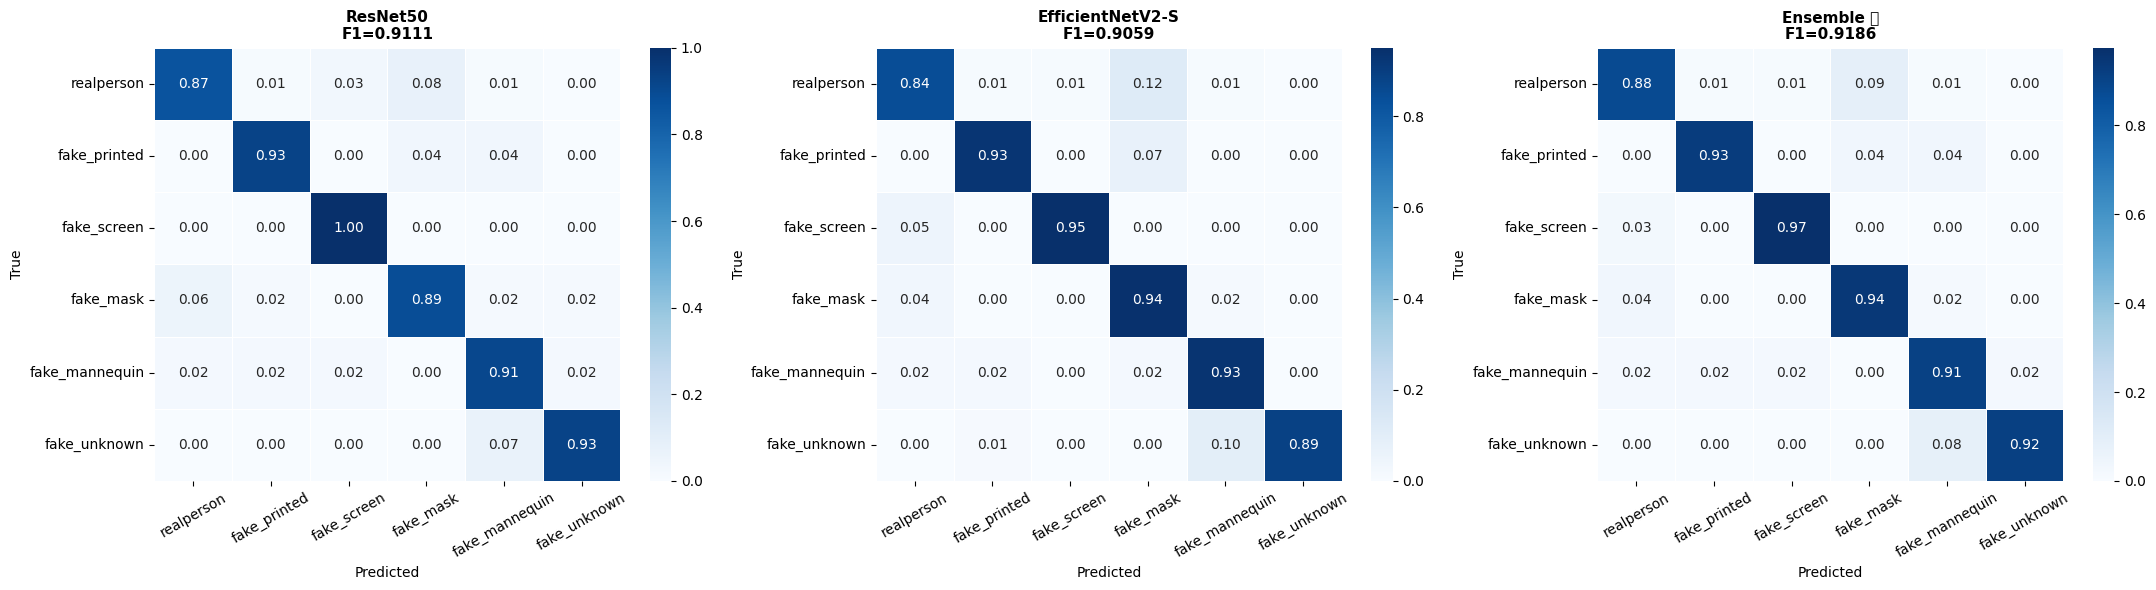

In [20]:
# Classification Report
print('\n📋 Ensemble Classification Report')
print(classification_report(gt, preds_ens, target_names=CLASS_NAMES, digits=4))

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (title, preds) in zip(axes, [
    ('ResNet50', preds_r), ('EfficientNetV2-S', preds_e), ('Ensemble ⭐', preds_ens)
]):
    cm = confusion_matrix(gt, preds).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='.2f',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', ax=ax, linewidths=0.5)
    f1 = f1_score(gt, preds, average='macro', zero_division=0)
    ax.set_title(f'{title}\nF1={f1:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Inference + submission.csv

In [22]:
def predict_ensemble_tta(model_r, model_e, test_dir, w_r, w_e, img_size=224):
    """5 TTA × 2 models = 10 forward passes per sample."""
    tta_tfms = get_tta_transforms(img_size)
    model_r.eval(); model_e.eval()
    avg_probs = None
    all_ids   = None
    total_w   = 0

    for t_idx, tfm in enumerate(tta_tfms):
        ds     = TestDataset(test_dir, transform=tfm)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        for model, w, name in [(model_r, w_r, 'ResNet50'), (model_e, w_e, 'EffNet')]:
            print(f'  TTA {t_idx+1}/{len(tta_tfms)} × {name}...')
            p_list, id_list = [], []
            with torch.no_grad():
                for imgs, ids in tqdm(loader, leave=False):
                    p = torch.softmax(model(imgs.to(DEVICE)), 1).cpu().numpy()
                    p_list.append(p); id_list.extend(ids)
            p_arr = np.concatenate(p_list) * w
            if avg_probs is None:
                avg_probs = p_arr; all_ids = id_list
            else:
                avg_probs += p_arr
            total_w += w

    avg_probs  /= total_w
    pred_labels = [IDX2CLASS[i] for i in avg_probs.argmax(1)]
    return all_ids, pred_labels, avg_probs


print('🔍 Ensemble TTA Inference (5 TTA × 2 models = 10 passes)...')
test_ids, test_preds, test_probs = predict_ensemble_tta(
    model_resnet, model_effnet, TEST_DIR, w_r=f1_r, w_e=f1_e
)

submission_df = pd.DataFrame({'id': test_ids, 'label': test_preds})
submission_df = submission_df.sort_values('id').reset_index(drop=True)
submission_df.to_csv(OUTPUT_CSV, index=False)

print(f'\n✅ Saved → {OUTPUT_CSV} ({len(submission_df)} rows)')
print(submission_df.head(6).to_string(index=False))

🔍 Ensemble TTA Inference (5 TTA × 2 models = 10 passes)...
  TTA 1/5 × ResNet50...


  0%|          | 0/13 [00:00<?, ?it/s]

  TTA 1/5 × EffNet...


  0%|          | 0/13 [00:00<?, ?it/s]

  TTA 2/5 × ResNet50...


...

  TTA 5/5 × ResNet50...


  0%|          | 0/13 [00:00<?, ?it/s]

  TTA 5/5 × EffNet...


  0%|          | 0/13 [00:00<?, ?it/s]


✅ Saved → submission_v3.csv (404 rows)
      id          label
test_001    fake_screen
test_002 fake_mannequin
test_003      fake_mask
test_004     realperson
test_005   fake_printed
test_006 fake_mannequin


In [23]:
# Verifikasi
print('='*55)
print('  ✅ SUBMISSION VERIFICATION')
print('='*55)
invalid = submission_df[~submission_df['label'].isin(set(CLASS_NAMES))]
print(f'  Rows   : {len(submission_df)}')
print(f'  Nulls  : {submission_df.isnull().sum().sum()}')
print(f'  Invalid: {len(invalid)}')
print(f'  Labels : {sorted(submission_df["label"].unique())}')
print(f'\n  File siap: {OUTPUT_CSV}')

  ✅ SUBMISSION VERIFICATION
  Rows   : 404
  Nulls  : 0
  Invalid: 0
  Labels : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']

  File siap: submission_v3.csv


---
## 📋 Ringkasan semua fix v2 → v3

| # | Bug | Root Cause | Fix |
|---|---|---|---|
| 1 | EffNet unfreeze 0 params | `list(backbone.children())` pada timm tidak return blok yang bisa di-index | Akses via `backbone.blocks.children()` + verifikasi dengan assert |
| 2 | Early stop terlalu agresif | Counter patience tidak di-reset saat pindah stage | `patience_count = 0` di awal setiap stage |
| 3 | TrAcc = 0.0 | Acc hanya dihitung untuk non-mix batch, tapi semua batch kena mix | Hitung soft accuracy untuk mixed batch juga |
| 4 | ResNet plateau ~89% | Hanya 2 layer yang unfreeze di semua stage | Unfreeze schedule progresif: 0→2→3→4 layers per stage |
| 5 | EffNet konvergen lambat | LR seragam untuk semua layer backbone | Layer-wise LR decay (decay=0.8 per block ke dalam) |